Data processiong


In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
df = pd.read_excel("online_shopping_dataset.csv.xlsx")
df = df.iloc[:100]
df

,product_name,price,discount,income_level,brand,rating,previous_purchase,time_on_site,buy
0,Headphones Sony,485,57,0,3,4.3,0,42,0
1,Adidas Shoes,115,21,2,2,4.1,0,51,1
2,Smart Watch,108,25,1,1,4.0,0,12,1
3,Laptop Dell,320,2,2,3,1.8,0,56,1
4,Headphones Sony,175,40,2,2,1.4,1,16,1
...,...,...,...,...,...,...,...,...,...
95,Camera Canon,88,0,1,3,1.7,1,15,1
96,Tablet,365,4,2,2,1.1,1,28,1
97,Headphones Sony,181,19,2,2,4.1,1,37,1
98,Tablet,152,7,0,1,3.4,1,55,1


In [55]:
df=df.drop(columns=["product_name", "income_level", "time_on_site","previous_purchase"])


df

,price,discount,brand,rating,buy
0,485,57,3,4.3,0
1,115,21,2,4.1,1
2,108,25,1,4.0,1
3,320,2,3,1.8,1
4,175,40,2,1.4,1
...,...,...,...,...,...
95,88,0,3,1.7,1
96,365,4,2,1.1,1
97,181,19,2,4.1,1
98,152,7,1,3.4,1


In [56]:
df

,price,discount,brand,rating,buy
0,485,57,3,4.3,0
1,115,21,2,4.1,1
2,108,25,1,4.0,1
3,320,2,3,1.8,1
4,175,40,2,1.4,1
...,...,...,...,...,...
95,88,0,3,1.7,1
96,365,4,2,1.1,1
97,181,19,2,4.1,1
98,152,7,1,3.4,1


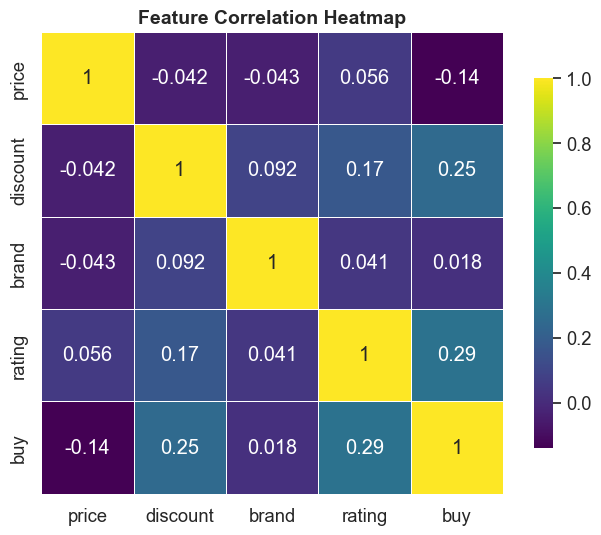

In [57]:
corr = df.corr()
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="viridis", 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

plt.title("Feature Correlation Heatmap", fontsize=14, weight="bold")
plt.show()


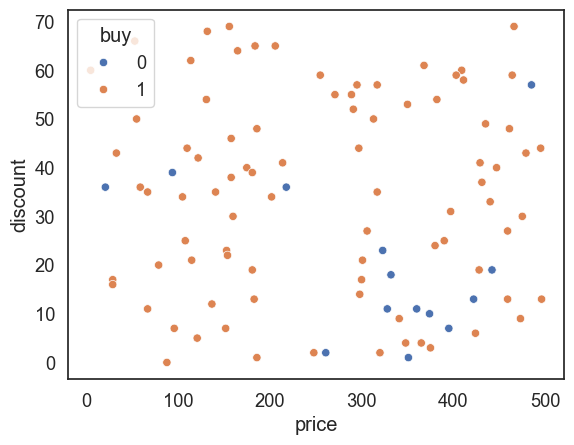

In [58]:
sns.scatterplot(data=df,x="price",y="discount",hue="buy")

plt.show()

In [59]:
df.isnull().sum()

price       0
discount    0
brand       0
rating      0
buy         0
dtype: int64

split data

In [60]:
data = df.to_numpy()
x = data[:,0:-1]
y = data[:,-1]
print(x.shape)
print(y.shape)


(100, 4)
(100,)


In [61]:
split_index = int(0.8* len(x))
x_train =x[:split_index]
y_train = y[: split_index]

x_test = x[split_index:]
y_test = y[split_index:]
print("X_train:",x_train.shape)
print("X_test:",x_test.shape)




X_train: (80, 4)
X_test: (20, 4)


Feature scaling

In [62]:
Mean_x_train = np.mean(x_test,axis=0)
Std_x_train = np.std(x_train,axis=0)

x_train_scaled = (x_train-Mean_x_train)/Std_x_train
x_test_scaled =(x_test-Mean_x_train)/Std_x_train
x_train_new = np.concatenate((np.ones((x_train_scaled.shape[0],1)),x_train_scaled),axis=1)
x_test_new = np.concatenate((np.ones((x_test_scaled.shape[0],1)),x_test_scaled),axis=1)


print(x_train_new[:5])
print("=================================================")
print(x_test_new[:5])

[[ 1.          1.7179503   1.47140886  1.53644256  1.01160087]
 [ 1.         -0.89088045 -0.33031627  0.68286336  0.84508221]
 [ 1.         -0.9402367  -0.13012459 -0.17071584  0.76182288]
 [ 1.          0.55455281 -1.28122676  1.53644256 -1.0698824 ]
 [ 1.         -0.46782681  0.62059421  0.68286336 -1.40291972]]
[[ 1.         -0.27745268  0.32030669 -0.17071584  1.42789752]
 [ 1.          0.75197784 -1.18113092  0.68286336 -1.15314173]
 [ 1.         -0.53833575  1.8217443   0.68286336 -0.07077043]
 [ 1.         -0.42552145  0.57054629  1.53644256  0.59530422]
 [ 1.          0.33597509  1.37131302  0.68286336  0.59530422]]


In [63]:
def hypothesis(theta,x):
    return np.dot(x,theta)
def sigmoid(z):
    return 1/(1+np.exp(-z))
def cost(x,y,theta):
    z = hypothesis(theta,x)
    h = sigmoid(z)
    m = len(y)
    c = (1/m)*(-y*np.log(h)-(1-y)*np.log(1-h)).sum()
    return c
def gradient(x,y,theta):
    z = hypothesis(theta,x)
    h = sigmoid(z)
    m = len(y)
    grad = (1/m)* np.matmul(x.T, (h-y))
    return grad
    

In [64]:
y_test = y_test.reshape(-1,1)
y_train = y_train.reshape(-1,1)


In [65]:
a=0
b=0
lr=0.1
costs=[]
theta = np.zeros((x_train_new.shape[1],1))
for i in range(1,1001):
    z= hypothesis(theta, x_train_new)
    h =sigmoid(z)
    grad = gradient(x_train_new,y_train,theta)
    cost_f =cost(x_train_new,y_train,theta)
    theta = theta - lr*grad
    print(f"Interation: {i:04d}: cost: {cost_f:.4f}")
    costs.append(cost_f)

Interation: 0001: cost: 0.6931
Interation: 0002: cost: 0.6743
Interation: 0003: cost: 0.6569
Interation: 0004: cost: 0.6408
Interation: 0005: cost: 0.6260
Interation: 0006: cost: 0.6122
Interation: 0007: cost: 0.5995
Interation: 0008: cost: 0.5877
Interation: 0009: cost: 0.5767
Interation: 0010: cost: 0.5665
Interation: 0011: cost: 0.5570
Interation: 0012: cost: 0.5482
Interation: 0013: cost: 0.5399
Interation: 0014: cost: 0.5321
Interation: 0015: cost: 0.5249
Interation: 0016: cost: 0.5181
Interation: 0017: cost: 0.5117
Interation: 0018: cost: 0.5057
Interation: 0019: cost: 0.5000
Interation: 0020: cost: 0.4947
Interation: 0021: cost: 0.4896
Interation: 0022: cost: 0.4849
Interation: 0023: cost: 0.4804
Interation: 0024: cost: 0.4761
Interation: 0025: cost: 0.4720
Interation: 0026: cost: 0.4682
Interation: 0027: cost: 0.4645
Interation: 0028: cost: 0.4610
Interation: 0029: cost: 0.4577
Interation: 0030: cost: 0.4545
Interation: 0031: cost: 0.4515
Interation: 0032: cost: 0.4486
Interati

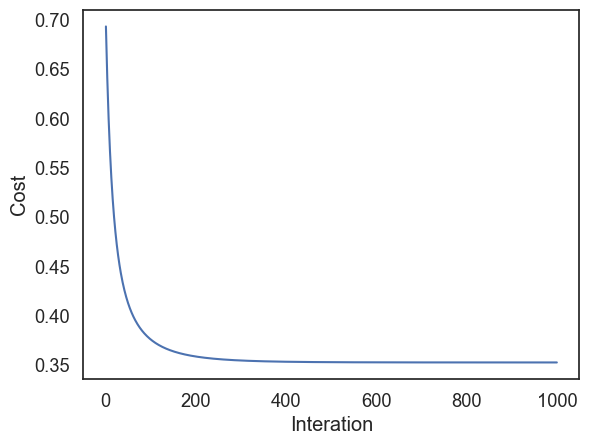

In [66]:
#plt Cost Vs Interation
plt.plot(range(1,1001),costs)
plt.xlabel("Interation")
plt.ylabel("Cost")
plt.show()

In [67]:
h = sigmoid(hypothesis(theta,x_test_new))
y_pre = np.where(h>0.5,1,0)
accuracy = np.mean(y_pre ==y_test)
print(f"Accuracy is : {accuracy*100: .2f}%")

Accuracy is :  90.00%


Example

In [68]:
def predict(x_new, theta):
    z = hypothesis(theta, x_new)
    h = sigmoid(z)
    return 1 if h >= 0.5 else 0

x_new = np.array([1,100, 50, 1, 5.1]) 


x_new = x_new.reshape(1, -1)

result = predict(x_new, theta)
print("Prediction:", "Buy" if result == 1 else "Not Buy")


Prediction: Buy


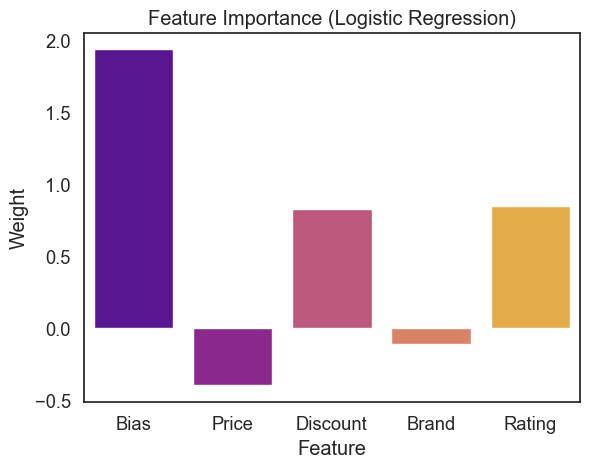

In [69]:
import pandas as pd
coef_df = pd.DataFrame({
    "Feature": ["Bias","Price","Discount","Brand","Rating"],
    "Weight": theta.flatten()
})
sns.barplot(data=coef_df, x="Feature", y="Weight", palette="plasma",hue="Feature",legend=False)
plt.title("Feature Importance (Logistic Regression)")
plt.show()
